# Industry 4.0 Predictive Maintenance with `qrc_sim`

This notebook shows a **simple and useful real-world use case** for `qrc_sim`:
a predictive-maintenance alerting workflow on the **AI4I 2020 Predictive Maintenance Dataset**, a Kaggle benchmark widely used in Industry 4.0 studies.

## Business framing
Imagine a production line instrumented with:
- air temperature,
- process temperature,
- rotational speed,
- torque,
- tool wear,
- and machine type.

Our practical goal is not an abstract benchmark. It is:

**Raise an alert when the machine is likely to fail within the next 20 sensor readings.**

## Why this is a good `qrc_sim` example
- it addresses a **real industrial problem**,
- it uses a **Kaggle maintenance benchmark** that is easy to reproduce,
- it uses the **core `qrc_sim` API** directly,
- it compares a plain linear baseline with **QRC-generated features**,
- and it produces a result that is easy to explain to a factory or maintenance team.


In [1]:
from pathlib import Path
import sys

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "qrc_sim").is_dir():
            return candidate
    raise RuntimeError("Could not find project root containing 'qrc_sim'.")

ROOT = find_project_root(Path.cwd().resolve())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from qrc_sim.industry4_predictive_maintenance import (
    DEFAULT_DATA_PATH,
    DEPENDENCY_STATUS,
    HAS_MATPLOTLIB,
    KAGGLE_URL,
    MISSING_OPTIONAL_DEPENDENCIES,
    MISSING_REQUIRED_DEPENDENCIES,
    NOTEBOOK_RUNTIME_READY,
    PUBLIC_MIRROR_URL,
    plot_alert_timeline,
    plot_metric_comparison,
    plot_prevalence,
    prepare_ai4i_alert_problem,
    run_industry4_experiment,
    save_figure,
    set_plot_style,
)

set_plot_style()

ARTIFACTS = ROOT / "qrc_sim" / "artifacts" / "industry4_maintenance"
ARTIFACTS.mkdir(parents=True, exist_ok=True)

DATA_PATH = ROOT / DEFAULT_DATA_PATH
print("Expected local CSV:", DATA_PATH)
print("Kaggle dataset     :", KAGGLE_URL)
print("Public mirror      :", PUBLIC_MIRROR_URL)
print("Artifacts          :", ARTIFACTS)
print("Plots enabled      :", HAS_MATPLOTLIB)
print("Runtime ready      :", NOTEBOOK_RUNTIME_READY)
print("Dependency status  :", DEPENDENCY_STATUS)
print("Missing required   :", MISSING_REQUIRED_DEPENDENCIES)
print("Missing optional   :", MISSING_OPTIONAL_DEPENDENCIES)

RUNTIME_READY = NOTEBOOK_RUNTIME_READY


Expected local CSV: /Users/anderson/Desktop/artigo2/data/ai4i2020.csv
Kaggle dataset     : https://www.kaggle.com/datasets/shivamb/ai4i-2020-predictive-maintenance-dataset
Public mirror      : https://raw.githubusercontent.com/SamyamoyRakshit/AI4I-2020-Predictive-Maintenance-Dataset__Linear-Regression/main/ai4i2020.csv
Artifacts          : /Users/anderson/Desktop/artigo2/qrc_sim/artifacts/industry4_maintenance
Plots enabled      : True
Runtime ready      : True
Dependency status  : {'numpy': True, 'pandas': True, 'matplotlib': True, 'qiskit': True, 'qrc_sim_core': True}
Missing required   : ()
Missing optional   : ()


## Stage 1. Load a Kaggle industrial maintenance benchmark

We work with the first 10,000 rows of AI4I 2020 so the notebook stays fast enough to be practical on a laptop.

AI4I is best treated as a **reproducible maintenance benchmark**, not as raw plant telemetry from one real factory.
The operational problem is still real: deciding when to raise a maintenance alert before a failure happens.

The target is not the current failure bit. Instead, we define a more useful maintenance target:

`alert = 1` if a machine failure appears within the next 20 rows.

That is closer to how an Industry 4.0 alerting system would be used in practice.


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,0.6,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,0.2,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,0.2,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,0.2,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,0.2,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


Features used: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Rows loaded  : 10000
Train end    : 7000
Val end      : 8500


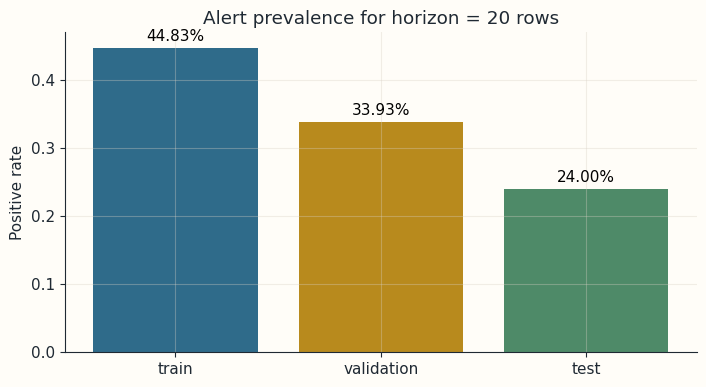


Correctness check
- Quantum inputs stay in [0, 1]: True
- Alert target has positives in all splits: True


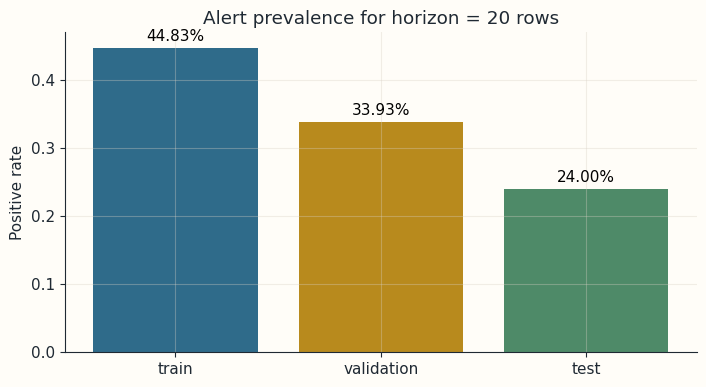

In [2]:
if not RUNTIME_READY:
    data = None
    print("Stage skipped. Missing required dependencies:", MISSING_REQUIRED_DEPENDENCIES)
else:
    data = prepare_ai4i_alert_problem(
        csv_path=DATA_PATH,
        n_rows=10_000,
        alert_horizon=20,
    )

    display(data.dataframe.head())
    print("Features used:", list(data.feature_names))
    print("Rows loaded  :", len(data.dataframe))
    print("Train end    :", data.train_end)
    print("Val end      :", data.val_end)

    fig = plot_prevalence(data)
    save_figure(fig, ARTIFACTS / "class_prevalence.png")
    display(fig)

    print("\nCorrectness check")
    print("- Quantum inputs stay in [0, 1]:", float(data.quantum_inputs.min()) >= 0.0 and float(data.quantum_inputs.max()) <= 1.0)
    print("- Alert target has positives in all splits:", data.target[:data.train_end].mean() > 0 and data.target[data.train_end:data.val_end].mean() > 0 and data.target[data.val_end:].mean() > 0)


**Reflection**

- Correct if the alert target is present in train, validation, and test.
- Correct if the quantum input is bounded in `[0, 1]`, because `AngleEncoder` expects a stable scale for rotations.


## Stage 2. Turn sensor rows into QRC features

This example deliberately uses the main `qrc_sim` building blocks:
- `AngleEncoder`
- `RandomReservoir`
- `QRCSimulator`
- `ReadoutModel`

We run in `reset_each_step` mode because this notebook treats each row as an industrial snapshot.
In other words, `qrc_sim` is acting here as a **nonlinear feature generator** for maintenance alerting.


In [3]:
if not RUNTIME_READY:
    results = None
    print("Stage skipped. Missing required dependencies:", MISSING_REQUIRED_DEPENDENCIES)
else:
    results = run_industry4_experiment(data)

    baseline_val = results["baseline"]["bundle"]["validation_metrics"]
    qrc_val = results["qrc"]["bundle"]["validation_metrics"]
    baseline_test = results["baseline"]["evaluation"]["metrics"]
    qrc_test = results["qrc"]["evaluation"]["metrics"]

    print("Validation metrics")
    print("Linear baseline:", baseline_val)
    print("QRC features    :", qrc_val)

    print("\nTest metrics")
    print("Linear baseline:", baseline_test)
    print("QRC features    :", qrc_test)

    print("\nCorrectness check")
    print("- Both models produce one score per test row:", len(results["baseline"]["evaluation"]["score"]) == len(results["qrc"]["evaluation"]["score"]) == len(results["splits"]["y_test"]))
    print("- QRC expands the representation:", results["qrc"]["features"].shape[1] > data.baseline_inputs.shape[1])


Validation metrics
Linear baseline: {'accuracy': 0.647999999999568, 'precision': 0.4860907759875753, 'recall': 0.6522593320222942, 'f1': 0.5570469793754913, 'tp': 332, 'fp': 351, 'fn': 177, 'tn': 640}
QRC features    : {'accuracy': 0.68999999999954, 'precision': 0.5359477124174249, 'recall': 0.6444007858533509, 'f1': 0.5851917925451039, 'tp': 328, 'fp': 284, 'fn': 181, 'tn': 707}

Test metrics
Linear baseline: {'accuracy': 0.6726666666662182, 'precision': 0.41822721597950285, 'recall': 0.9305555555529708, 'f1': 0.5770887161947473, 'tp': 335, 'fp': 466, 'fn': 25, 'tn': 674}
QRC features    : {'accuracy': 0.7099999999995267, 'precision': 0.43567753001640536, 'recall': 0.7055555555535957, 'f1': 0.5387062561546023, 'tp': 254, 'fp': 329, 'fn': 106, 'tn': 811}

Correctness check
- Both models produce one score per test row: True
- QRC expands the representation: True


**Reflection**

- Correct if both pipelines run on the same train/validation/test split and the same alert target.
- This is the crucial fairness condition: the only thing changing is the representation, not the downstream alerting protocol.


## Stage 3. Compare operational alert trade-offs

The baseline uses the normalized sensor columns directly.

The QRC pipeline first maps those columns into a quantum reservoir and only then trains the same kind of linear readout.

This lets us answer a practical question:

**How does `qrc_sim` change the trade-off between missed failures and unnecessary maintenance alerts?**


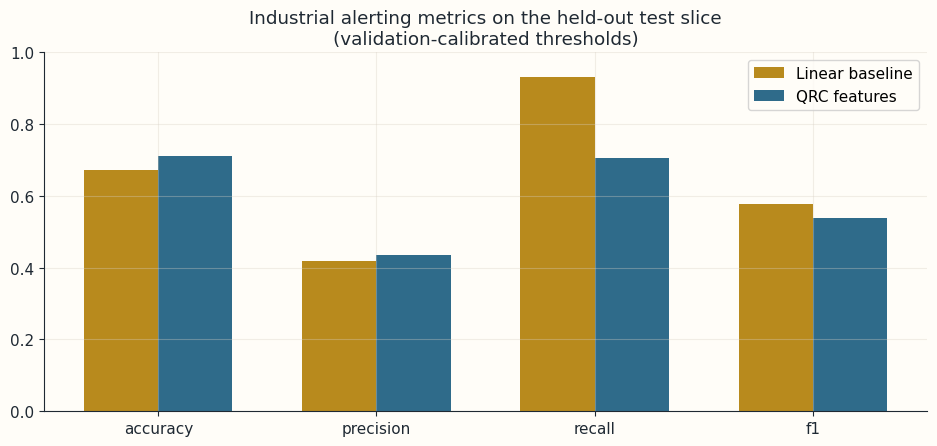

Headline comparison on the held-out test split
Baseline F1        : 0.577
QRC F1             : 0.539
Baseline precision : 0.418
QRC precision      : 0.436
Baseline recall    : 0.931
QRC recall         : 0.706
Baseline FP / FN   : 466 / 25
QRC FP / FN        : 329 / 106

Correctness check
- Baseline threshold chosen inside validation-score range: True
- QRC threshold chosen inside validation-score range     : True


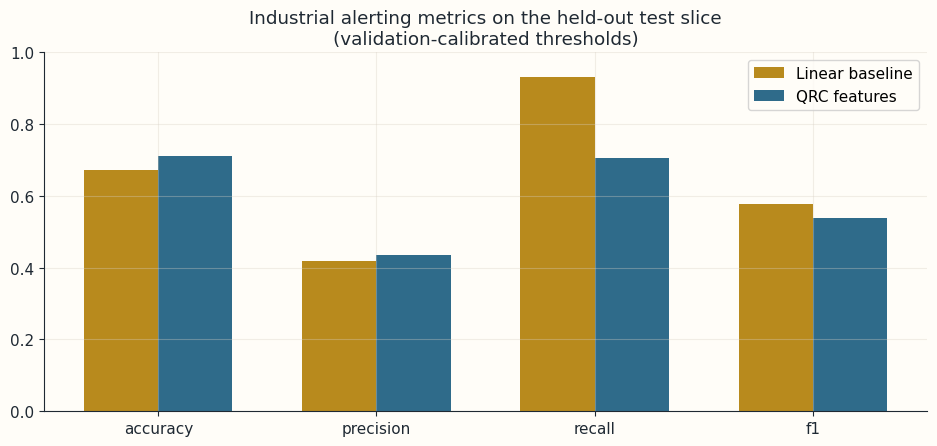

In [4]:
if not RUNTIME_READY:
    print("Stage skipped. Missing required dependencies:", MISSING_REQUIRED_DEPENDENCIES)
else:
    fig = plot_metric_comparison(results)
    save_figure(fig, ARTIFACTS / "metric_comparison.png")
    display(fig)

    baseline_test = results["baseline"]["evaluation"]["metrics"]
    qrc_test = results["qrc"]["evaluation"]["metrics"]

    print("Headline comparison on the held-out test split")
    print(f"Baseline F1        : {baseline_test['f1']:.3f}")
    print(f"QRC F1             : {qrc_test['f1']:.3f}")
    print(f"Baseline precision : {baseline_test['precision']:.3f}")
    print(f"QRC precision      : {qrc_test['precision']:.3f}")
    print(f"Baseline recall    : {baseline_test['recall']:.3f}")
    print(f"QRC recall         : {qrc_test['recall']:.3f}")
    print(f"Baseline FP / FN   : {baseline_test['fp']} / {baseline_test['fn']}")
    print(f"QRC FP / FN        : {qrc_test['fp']} / {qrc_test['fn']}")

    print("\nCorrectness check")
    baseline_range = results["baseline"]["bundle"]["validation_score_range"]
    qrc_range = results["qrc"]["bundle"]["validation_score_range"]
    print("- Baseline threshold chosen inside validation-score range:", baseline_range[0] <= results["baseline"]["evaluation"]["threshold"] <= baseline_range[1])
    print("- QRC threshold chosen inside validation-score range     :", qrc_range[0] <= results["qrc"]["evaluation"]["threshold"] <= qrc_range[1])


**Reflection**

- In a factory context, different teams optimize different metrics.
- In this benchmark, the plain linear baseline catches more future failures, while the QRC pipeline reduces false alarms and increases precision.
- That trade-off is operationally meaningful: some plants prefer fewer unnecessary inspections, while others prefer maximum failure coverage.


## Stage 4. Inspect the alert timeline

A metric table is useful, but operations teams often want to see the actual alert behavior over a stretch of sensor readings.


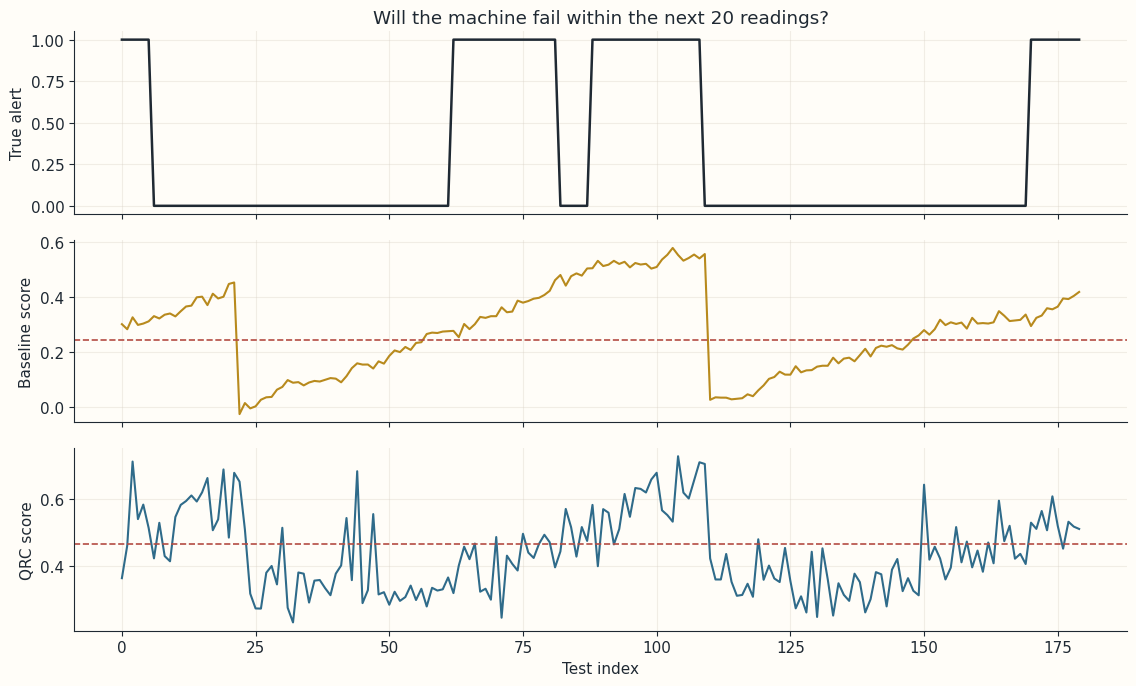

Thresholds selected on validation
Baseline threshold: 0.24421297509733775
QRC threshold     : 0.46588365995843417


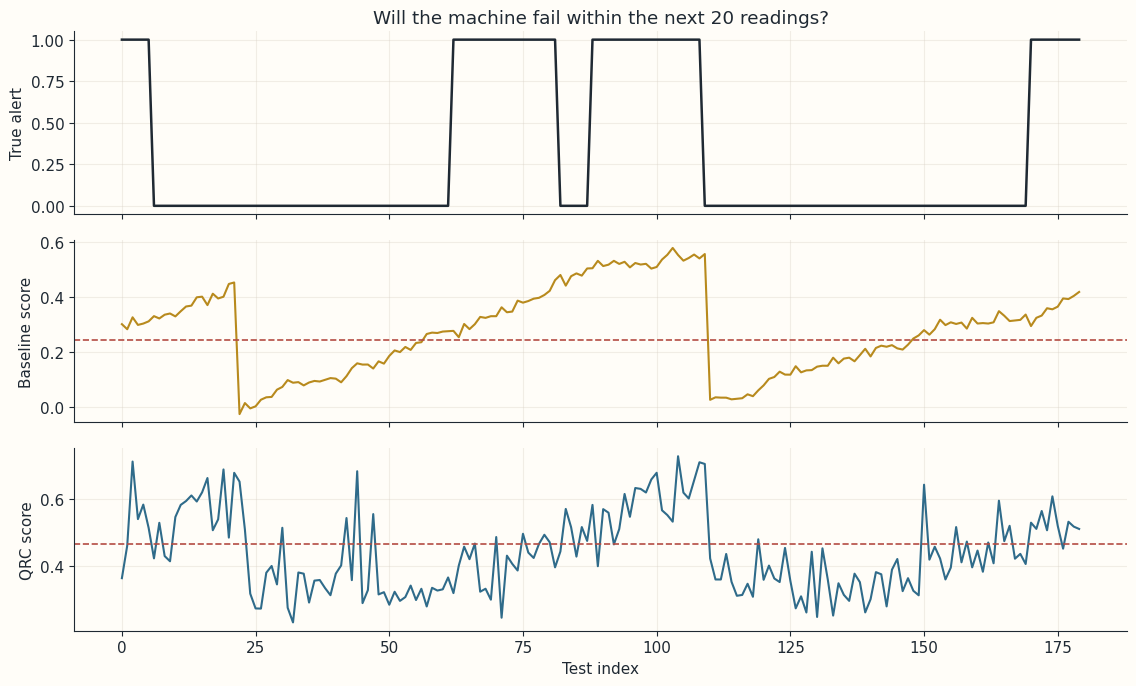

In [5]:
if not RUNTIME_READY:
    print("Stage skipped. Missing required dependencies:", MISSING_REQUIRED_DEPENDENCIES)
else:
    fig = plot_alert_timeline(data, results, start=0, length=180)
    save_figure(fig, ARTIFACTS / "alert_timeline.png")
    display(fig)

    print("Thresholds selected on validation")
    print("Baseline threshold:", results["baseline"]["evaluation"]["threshold"])
    print("QRC threshold     :", results["qrc"]["evaluation"]["threshold"])


**Reflection**

- Correct if the QRC score can be interpreted as a smooth alert score and not only as a hard class.
- That matters in Industry 4.0/5.0 deployments because maintenance planners typically want a risk ranking, not just a binary light.


## Closing Takeaway

This notebook demonstrates a concrete real-world use of `qrc_sim`:

- a **Kaggle maintenance benchmark**,
- a real **industrial alerting target**,
- direct use of the `qrc_sim` API,
- and a clean comparison between classical raw features and QRC-derived features.

In this particular benchmark, `qrc_sim` does not simply dominate the classical baseline.
Instead, it changes the alert profile: fewer false alarms, higher precision, and a different recall regime.
That is still a useful industrial result, because maintenance systems are deployed under workload and risk constraints, not only leaderboard metrics.

If you later replace AI4I with plant-specific data, the same workflow remains:
1. normalize sensors,
2. define an operational target,
3. generate QRC features with `QRCSimulator`,
4. fit a lightweight readout,
5. and calibrate the decision threshold on validation data.
